In [1]:
import sys
import subprocess
import os
import json
import warnings

def install_requirements():
    required_packages = [
        'pandas',
        'numpy',
        'lightgbm',
        'scikit-learn',
        'joblib',
        'pyarrow',
        'torch',
        'scipy'
    ]

    for package in required_packages:
        import_name = 'sklearn' if package == 'scikit-learn' else package
        try:
            __import__(import_name)
        except ImportError:
            print(f"Package '{package}' not found. Installing")
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', package]
            )

    print("All dependencies installed.")

install_requirements()

import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
import torch
import torch.nn as nn

from scipy.special import expit
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings(
    'ignore',
    category=FutureWarning
)

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Evaluation device: {device}")

All dependencies installed.
Evaluation device: cpu


In [2]:
SUPERVISED_MODEL_CANDIDATES = [
    'FinanceRiskManager_winner.pkl',
    'sentinel_x_winner.pkl'
]

POLICY_PATH = 'tri_state_cost_report.json'
AE_MODEL_PATH = 'abuse_ring_sentinel_autoencoder.pth'
AE_ARTIFACT_PATH = 'abuse_ring_sentinel_artifacts.pkl'

M5_PATH = 'calib_m5.parquet'
M6_REAL_PATH = 'test_m6_real.parquet'
M6_STRESS_PATH = 'test_m6_stress.parquet'

FINAL_REPORT_PATH = 'm6_final_review_reduction_report.json'
FINAL_PREDICTIONS_PATH = 'm6_final_review_reduction_predictions.csv'
ABLATION_PATH = 'm6_review_reduction_ablation.csv'

AUTO_RESOLVE_MAX_FRAUD_RATE = 0.01
AUTO_RESOLVE_MIN_M5_ROWS = 50

AE_HIGH_ANOMALY_PERCENTILE = 95

print(
    f"Auto-resolve target fraud rate: "
    f"{AUTO_RESOLVE_MAX_FRAUD_RATE * 100:.2f}%"
)

Auto-resolve target fraud rate: 1.00%


In [3]:
supervised_model_path = None

for candidate in SUPERVISED_MODEL_CANDIDATES:
    if os.path.exists(candidate):
        supervised_model_path = candidate
        break

required_paths = [
    POLICY_PATH,
    AE_MODEL_PATH,
    AE_ARTIFACT_PATH,
    M5_PATH,
    M6_REAL_PATH,
    M6_STRESS_PATH
]

if supervised_model_path is None:
    raise FileNotFoundError(
        'No supervised winner found.'
    )

for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file missing: {path}"
        )

supervised_model = joblib.load(
    supervised_model_path
)

ae_artifacts = joblib.load(
    AE_ARTIFACT_PATH
)

with open(
    POLICY_PATH,
    'r',
    encoding='utf-8'
) as f:
    policy = json.load(f)

thresholds = policy[
    'deployment_thresholds'
]

t_low = float(
    thresholds[
        'manual_review_min_risk'
    ]
)

t_high = float(
    thresholds[
        'manual_review_max_risk'
    ]
)

financial = policy[
    'financial_assumptions'
]

review_assumptions = policy[
    'review_assumptions'
]

feature_columns = list(
    joblib.load(
        'preprocessing_artifacts.pkl'
    )['feature_columns']
)

prep_artifacts = joblib.load(
    'preprocessing_artifacts.pkl'
)

categorical_features = list(
    prep_artifacts[
        'categorical_features'
    ]
)

category_maps = prep_artifacts[
    'category_maps'
]

winning_model_name = prep_artifacts[
    'winning_model_name'
]

numerical_features = list(
    ae_artifacts[
        'numerical_features'
    ]
)

ae_medians = pd.Series(
    ae_artifacts[
        'imputation_medians'
    ]
)

ae_lower_clip = pd.Series(
    ae_artifacts[
        'lower_clip'
    ]
)

ae_upper_clip = pd.Series(
    ae_artifacts[
        'upper_clip'
    ]
)

ae_scaler = ae_artifacts[
    'scaler'
]

ae_high_threshold = float(
    ae_artifacts[
        'anomaly_threshold'
    ]
)

print(
    f"Supervised model: {supervised_model_path}"
)

print(
    f"Winning model type: {winning_model_name}"
)

print(
    f"Phase 2 thresholds: "
    f"{t_low:.6f} to {t_high:.6f}"
)

print(
    f"AE high-anomaly threshold: "
    f"{ae_high_threshold:.6f}"
)

Supervised model: FinanceRiskManager_winner.pkl
Winning model type: Focal_Loss_LightGBM
Phase 2 thresholds: 0.210000 to 0.520000
AE high-anomaly threshold: 0.723460


In [4]:
class FraudDetector(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64, 16),
        latent_dim=8,
        dropout_p=0.10
    ):
        super().__init__()

        h1, h2, h3 = hidden_dims

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.LayerNorm(h1),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h1, h2),
            nn.LayerNorm(h2),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h2, h3),
            nn.LayerNorm(h3),
            nn.GELU(),
            nn.Linear(h3, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h3),
            nn.LayerNorm(h3),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h3, h2),
            nn.LayerNorm(h2),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h2, h1),
            nn.LayerNorm(h1),
            nn.GELU(),
            nn.Linear(h1, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


checkpoint = torch.load(
    AE_MODEL_PATH,
    map_location=device,
    weights_only=False
)

autoencoder = FraudDetector(
    input_dim=int(
        checkpoint['input_dim']
    ),
    hidden_dims=tuple(
        checkpoint['hidden_dims']
    ),
    latent_dim=int(
        checkpoint['latent_dim']
    ),
    dropout_p=float(
        checkpoint['dropout_p']
    )
).to(device)

autoencoder.load_state_dict(
    checkpoint['model_state_dict']
)

autoencoder.eval()

print("Autoencoder loaded successfully.")

Autoencoder loaded successfully.


In [5]:
def add_temporal_features(df):
    df = df.copy()

    if 'TransactionDT' not in df.columns:
        raise ValueError(
            'TransactionDT column missing.'
        )

    df['TransactionHour'] = (
        (df['TransactionDT'] // 3600) % 24
    ).astype(np.int8)

    df['TransactionDay'] = (
        df['TransactionDT'] // (24 * 3600)
    ).astype(np.int32)

    df['HourSin'] = np.sin(
        2 * np.pi * df['TransactionHour'] / 24
    ).astype(np.float32)

    df['HourCos'] = np.cos(
        2 * np.pi * df['TransactionHour'] / 24
    ).astype(np.float32)

    df.drop(
        columns=['TransactionDT'],
        inplace=True
    )

    return df


def prepare_lgb_features(df):
    transformed = add_temporal_features(
        df
    )

    missing = [
        col
        for col in feature_columns
        if col not in transformed.columns
    ]

    if missing:
        raise ValueError(
            f'LightGBM feature mismatch: {missing}'
        )

    X = transformed[
        feature_columns
    ].copy()

    for col in categorical_features:
        categories = pd.Index(
            category_maps[col]
        )

        X[col] = pd.Categorical(
            X[col].astype('string'),
            categories=categories
        )

    return X


def prepare_ae_features(df):
    transformed = add_temporal_features(
        df
    )

    missing = [
        col
        for col in numerical_features
        if col not in transformed.columns
    ]

    if missing:
        raise ValueError(
            f'Autoencoder feature mismatch: {missing}'
        )

    X = transformed[
        numerical_features
    ].copy()

    X = X.fillna(
        ae_medians
    )

    X = X.clip(
        lower=ae_lower_clip,
        upper=ae_upper_clip,
        axis=1
    )

    return X


def score_models(df):
    X_lgb = prepare_lgb_features(
        df
    )

    raw_scores = supervised_model.predict(
        X_lgb,
        num_iteration=supervised_model.best_iteration
    )

    if winning_model_name == 'Focal_Loss_LightGBM':
        fraud_probability = expit(
            raw_scores
        )
    else:
        fraud_probability = np.asarray(
            raw_scores,
            dtype=np.float64
        )

    fraud_probability = np.clip(
        fraud_probability,
        0.0,
        1.0
    )

    X_ae = prepare_ae_features(
        df
    )

    X_ae_scaled = ae_scaler.transform(
        X_ae
    ).astype(np.float32)

    tensor = torch.tensor(
        X_ae_scaled,
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        reconstructed = autoencoder(
            tensor
        )

        mse = torch.mean(
            (
                tensor
                -
                reconstructed
            ) ** 2,
            dim=1
        ).cpu().numpy()

    anomaly_flag = (
        mse > ae_high_threshold
    )

    return (
        fraud_probability,
        mse,
        anomaly_flag
    )

In [6]:
m5_df = pd.read_parquet(
    M5_PATH
)

m5_probs, m5_mse, m5_anomaly = score_models(
    m5_df
)

m5_labels = m5_df[
    'isFraud'
].to_numpy(
    dtype=np.int8
)

m5_review_mask = (
    (m5_probs >= t_low)
    &
    (m5_probs <= t_high)
)

candidate_percentiles = [
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80
]

m5_legit_review_mse = m5_mse[
    m5_review_mask
    &
    (m5_labels == 0)
]

if len(m5_legit_review_mse) == 0:
    raise ValueError(
        'No legitimate M5 transactions exist in the Phase 2 review band.'
    )

calibration_rows = []

for percentile in candidate_percentiles:

    threshold = float(
        np.percentile(
            m5_legit_review_mse,
            percentile
        )
    )

    auto_resolve = (
        m5_review_mask
        &
        (m5_mse <= threshold)
    )

    resolved_count = int(
        auto_resolve.sum()
    )

    resolved_fraud = int(
        (
            auto_resolve
            &
            (m5_labels == 1)
        ).sum()
    )

    resolved_fraud_rate = (
        resolved_fraud / resolved_count
        if resolved_count > 0
        else 1.0
    )

    calibration_rows.append({
        'percentile': percentile,
        'threshold': threshold,
        'auto_resolved': resolved_count,
        'resolved_fraud': resolved_fraud,
        'resolved_fraud_rate': resolved_fraud_rate
    })

calibration_df = pd.DataFrame(
    calibration_rows
)

eligible = calibration_df[
    (
        calibration_df[
            'auto_resolved'
        ]
        >= AUTO_RESOLVE_MIN_M5_ROWS
    )
    &
    (
        calibration_df[
            'resolved_fraud_rate'
        ]
        <= AUTO_RESOLVE_MAX_FRAUD_RATE
    )
]

if eligible.empty:
    auto_resolve_threshold = 0.0
    selected_percentile = None
    print(
        "No M5 threshold satisfied the auto-resolve safety constraint."
    )
else:
    selected_row = eligible.iloc[-1]

    auto_resolve_threshold = float(
        selected_row[
            'threshold'
        ]
    )

    selected_percentile = int(
        selected_row[
            'percentile'
        ]
    )

print(
    "M5 auto-resolve calibration"
)

print(
    calibration_df.to_string(
        index=False
    )
)

print(
    f"Selected auto-resolve threshold: "
    f"{auto_resolve_threshold:.6f}"
)

print(
    f"Selected M5 percentile: "
    f"{selected_percentile}"
)

C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

M5 auto-resolve calibration
 percentile  threshold  auto_resolved  resolved_fraud  resolved_fraud_rate
         10   0.024259            220               2             0.009091
         20   0.047731            444               9             0.020270
         30   0.080242            669              17             0.025411
         40   0.119143            897              28             0.031215
         50   0.173852           1123              36             0.032057
         60   0.242584           1349              45             0.033358
         70   0.340861           1597              76             0.047589
         80   0.484185           1828              90             0.049234
Selected auto-resolve threshold: 0.024259
Selected M5 percentile: 10


In [7]:
def route_policy(
    probabilities,
    mse_scores,
    anomaly_flags,
    auto_resolve_threshold
):
    approve_mask = (
        probabilities < t_low
    )

    review_mask = (
        (probabilities >= t_low)
        &
        (probabilities <= t_high)
    )

    block_mask = (
        probabilities > t_high
    )

    auto_resolve_mask = (
        review_mask
        &
        (
            mse_scores
            <= auto_resolve_threshold
        )
    )

    priority_review_mask = (
        review_mask
        &
        ~auto_resolve_mask
        &
        anomaly_flags
    )

    standard_review_mask = (
        review_mask
        &
        ~auto_resolve_mask
        &
        ~anomaly_flags
    )

    final_approve_mask = (
        approve_mask
        |
        auto_resolve_mask
    )

    return {
        'approve_mask': final_approve_mask,
        'auto_resolve_mask': auto_resolve_mask,
        'priority_review_mask': priority_review_mask,
        'standard_review_mask': standard_review_mask,
        'review_mask': (
            priority_review_mask
            |
            standard_review_mask
        ),
        'block_mask': block_mask
    }


def calculate_cost(
    amounts,
    labels,
    routing
):
    approve_mask = routing[
        'approve_mask'
    ]

    review_mask = routing[
        'review_mask'
    ]

    block_mask = routing[
        'block_mask'
    ]

    approve_fraud = (
        approve_mask
        &
        (labels == 1)
    )

    block_legit = (
        block_mask
        &
        (labels == 0)
    )

    review_fraud = (
        review_mask
        &
        (labels == 1)
    )

    review_legit = (
        review_mask
        &
        (labels == 0)
    )

    review_fraud_count = int(
        review_fraud.sum()
    )

    review_legit_count = int(
        review_legit.sum()
    )

    fraud_capture_rate = float(
        review_assumptions[
            'fraud_capture_rate'
        ]
    )

    legit_approval_rate = float(
        review_assumptions[
            'legitimate_approval_rate'
        ]
    )

    review_fraud_missed = int(
        round(
            review_fraud_count
            * (1.0 - fraud_capture_rate)
        )
    )

    review_legit_rejected = int(
        round(
            review_legit_count
            * (1.0 - legit_approval_rate)
        )
    )

    fn_count = int(
        approve_fraud.sum()
        +
        review_fraud_missed
    )

    fp_count = int(
        block_legit.sum()
        +
        review_legit_rejected
    )

    fn_amount = float(
        amounts[
            approve_fraud
        ].sum()
    )

    review_fraud_amount = float(
        amounts[
            review_fraud
        ].sum()
    )

    review_fraud_missed_amount = (
        review_fraud_amount
        *
        (
            review_fraud_missed
            /
            review_fraud_count
        )
        if review_fraud_count > 0
        else 0.0
    )

    fp_amount = float(
        amounts[
            block_legit
        ].sum()
        *
        float(
            financial[
                'profit_margin_pct'
            ]
        )
    )

    review_legit_amount = float(
        amounts[
            review_legit
        ].sum()
    )

    review_legit_rejected_amount = (
        review_legit_amount
        *
        (
            review_legit_rejected
            /
            review_legit_count
        )
        if review_legit_count > 0
        else 0.0
    )

    fp_amount += (
        review_legit_rejected_amount
        *
        float(
            financial[
                'profit_margin_pct'
            ]
        )
    )

    fn_cost = (
        fn_amount
        +
        approve_fraud.sum()
        *
        float(
            financial[
                'chargeback_fee_usd'
            ]
        )
        +
        review_fraud_missed_amount
        +
        review_fraud_missed
        *
        float(
            financial[
                'chargeback_fee_usd'
            ]
        )
    )

    fp_cost = (
        fp_amount
        +
        block_legit.sum()
        *
        float(
            financial[
                'false_positive_cost_usd'
            ]
        )
        +
        review_legit_rejected
        *
        float(
            financial[
                'false_positive_cost_usd'
            ]
        )
    )

    review_cost = (
        review_mask.sum()
        *
        float(
            financial[
                'manual_review_cost_usd'
            ]
        )
    )

    return {
        'total_cost': float(
            fn_cost + fp_cost + review_cost
        ),
        'false_negative_cost': float(
            fn_cost
        ),
        'false_positive_cost': float(
            fp_cost
        ),
        'review_operational_cost': float(
            review_cost
        ),
        'false_negative_count': fn_count,
        'false_positive_count': fp_count
    }

In [8]:
def evaluate_dataset(
    name,
    df,
    use_auto_resolve,
    auto_resolve_threshold
):
    probabilities, mse_scores, anomaly_flags = score_models(
        df
    )

    labels = df[
        'isFraud'
    ].to_numpy(
        dtype=np.int8
    )

    amounts = df[
        'TransactionAmt'
    ].to_numpy(
        dtype=np.float64
    )

    if use_auto_resolve:
        routing = route_policy(
            probabilities,
            mse_scores,
            anomaly_flags,
            auto_resolve_threshold
        )
    else:
        routing = {
            'approve_mask': probabilities < t_low,
            'auto_resolve_mask': np.zeros(
                len(df),
                dtype=bool
            ),
            'priority_review_mask': np.zeros(
                len(df),
                dtype=bool
            ),
            'standard_review_mask': (
                (probabilities >= t_low)
                &
                (probabilities <= t_high)
            ),
            'review_mask': (
                (probabilities >= t_low)
                &
                (probabilities <= t_high)
            ),
            'block_mask': probabilities > t_high
        }

    block_mask = routing[
        'block_mask'
    ]

    block_precision = precision_score(
        labels,
        block_mask.astype(np.int8),
        zero_division=0
    )

    block_recall = recall_score(
        labels,
        block_mask.astype(np.int8),
        zero_division=0
    )

    block_f1 = f1_score(
        labels,
        block_mask.astype(np.int8),
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        labels,
        block_mask.astype(np.int8)
    ).ravel()

    auto_resolve_mask = routing[
        'auto_resolve_mask'
    ]

    auto_resolve_count = int(
        auto_resolve_mask.sum()
    )

    auto_resolve_fraud = int(
        (
            auto_resolve_mask
            &
            (labels == 1)
        ).sum()
    )

    auto_resolve_fraud_rate = (
        auto_resolve_fraud
        /
        auto_resolve_count
        if auto_resolve_count > 0
        else 0.0
    )

    cost = calculate_cost(
        amounts,
        labels,
        routing
    )

    approve_all_cost = float(
        amounts[
            labels == 1
        ].sum()
        +
        (
            labels == 1
        ).sum()
        *
        float(
            financial[
                'chargeback_fee_usd'
            ]
        )
    )

    cost[
        'approve_all_baseline_cost'
    ] = approve_all_cost

    cost[
        'loss_reduction_vs_approve_all_pct'
    ] = (
        (
            approve_all_cost
            -
            cost['total_cost']
        )
        /
        approve_all_cost
        *
        100
    )

    result = {
        'routing': {
            'approve': int(
                routing['approve_mask'].sum()
            ),
            'auto_resolve': auto_resolve_count,
            'priority_review': int(
                routing[
                    'priority_review_mask'
                ].sum()
            ),
            'standard_review': int(
                routing[
                    'standard_review_mask'
                ].sum()
            ),
            'total_review': int(
                routing[
                    'review_mask'
                ].sum()
            ),
            'block': int(
                block_mask.sum()
            )
        },
        'decision_metrics': {
            'block_precision': float(
                block_precision
            ),
            'block_recall': float(
                block_recall
            ),
            'block_f1': float(
                block_f1
            ),
            'true_positives': int(tp),
            'false_positives': int(fp),
            'false_negatives': int(fn),
            'true_negatives': int(tn)
        },
        'auto_resolve_metrics': {
            'count': auto_resolve_count,
            'fraud_count': auto_resolve_fraud,
            'fraud_rate': float(
                auto_resolve_fraud_rate
            )
        },
        'financial_metrics': cost
    }

    print(
        f"--- {name} ---"
    )

    print(
        f"Approve:          "
        f"{result['routing']['approve']:,}"
    )

    print(
        f"Auto-resolve:     "
        f"{result['routing']['auto_resolve']:,}"
    )

    print(
        f"Priority review:  "
        f"{result['routing']['priority_review']:,}"
    )

    print(
        f"Standard review:  "
        f"{result['routing']['standard_review']:,}"
    )

    print(
        f"Block:            "
        f"{result['routing']['block']:,}"
    )

    print(
        f"Block precision:  "
        f"{block_precision:.6f}"
    )

    print(
        f"Block recall:     "
        f"{block_recall:.6f}"
    )

    print(
        f"Auto-resolve fraud rate: "
        f"{auto_resolve_fraud_rate:.6f}"
    )

    print(
        f"Total cost:       "
        f"${cost['total_cost']:,.2f}"
    )

    return result, probabilities, mse_scores, routing

In [9]:
m6_datasets = {
    'M6 Real': pd.read_parquet(
        M6_REAL_PATH
    ),
    'M6 Stress': pd.read_parquet(
        M6_STRESS_PATH
    )
}

baseline_results = {}
production_results = {}
prediction_rows = []

for name, df in m6_datasets.items():

    baseline, baseline_probs, baseline_mse, baseline_routing = evaluate_dataset(
        name + ' Model 1 Only',
        df,
        False,
        0.0
    )

    production, probs, mse_scores, routing = evaluate_dataset(
        name + ' Model 1 + Abuse-Ring Sentinel',
        df,
        True,
        auto_resolve_threshold
    )

    baseline_results[name] = baseline
    production_results[name] = production

    labels = df[
        'isFraud'
    ].to_numpy(
        dtype=np.int8
    )

    decisions = np.select(
        [
            routing['block_mask'],
            routing['priority_review_mask'],
            routing['standard_review_mask'],
            routing['auto_resolve_mask']
        ],
        [
            'BLOCK',
            'PRIORITY_REVIEW',
            'REVIEW',
            'AUTO_RESOLVE'
        ],
        default='APPROVE'
    )

    prediction_rows.append(
        pd.DataFrame({
            'dataset': name,
            'actual_fraud': labels,
            'fraud_probability': probs,
            'reconstruction_mse': mse_scores,
            'ae_high_anomaly_flag': (
                mse_scores > ae_high_threshold
            ),
            'decision': decisions,
            'auto_resolve': routing[
                'auto_resolve_mask'
            ],
            'priority_review': routing[
                'priority_review_mask'
            ]
        })
    )

C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

--- M6 Real Model 1 Only ---
Approve:          6,230
Auto-resolve:     0
Priority review:  0
Standard review:  2,494
Block:            135
Block precision:  0.688889
Block recall:     0.339416
Auto-resolve fraud rate: 0.000000
Total cost:       $23,526.02


C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

--- M6 Real Model 1 + Abuse-Ring Sentinel ---
Approve:          6,450
Auto-resolve:     220
Priority review:  470
Standard review:  1,804
Block:            135
Block precision:  0.688889
Block recall:     0.339416
Auto-resolve fraud rate: 0.013636
Total cost:       $22,977.10


C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

--- M6 Stress Model 1 Only ---
Approve:          6,230
Auto-resolve:     0
Priority review:  0
Standard review:  2,494
Block:            135
Block precision:  0.688889
Block recall:     0.339416
Auto-resolve fraud rate: 0.000000
Total cost:       $21,455.53


C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

--- M6 Stress Model 1 + Abuse-Ring Sentinel ---
Approve:          6,450
Auto-resolve:     220
Priority review:  470
Standard review:  1,804
Block:            135
Block precision:  0.688889
Block recall:     0.339416
Auto-resolve fraud rate: 0.013636
Total cost:       $20,633.82


In [10]:
ablation_rows = []

for name in m6_datasets:

    baseline = baseline_results[
        name
    ]

    production = production_results[
        name
    ]

    ablation_rows.append({
        'dataset': name,
        'policy': 'Model 1 Only',
        'auto_resolve': 0,
        'review': baseline[
            'routing'
        ]['total_review'],
        'block': baseline[
            'routing'
        ]['block'],
        'block_precision': baseline[
            'decision_metrics'
        ]['block_precision'],
        'block_recall': baseline[
            'decision_metrics'
        ]['block_recall'],
        'total_cost': baseline[
            'financial_metrics'
        ]['total_cost'],
        'loss_reduction_vs_approve_all_pct': baseline[
            'financial_metrics'
        ]['loss_reduction_vs_approve_all_pct']
    })

    ablation_rows.append({
        'dataset': name,
        'policy': 'Model 1 + Abuse-Ring Sentinel',
        'auto_resolve': production[
            'routing'
        ]['auto_resolve'],
        'review': production[
            'routing'
        ]['total_review'],
        'block': production[
            'routing'
        ]['block'],
        'block_precision': production[
            'decision_metrics'
        ]['block_precision'],
        'block_recall': production[
            'decision_metrics'
        ]['block_recall'],
        'total_cost': production[
            'financial_metrics'
        ]['total_cost'],
        'loss_reduction_vs_approve_all_pct': production[
            'financial_metrics'
        ]['loss_reduction_vs_approve_all_pct']
    })

ablation_df = pd.DataFrame(
    ablation_rows
)

ablation_df.to_csv(
    ABLATION_PATH,
    index=False
)

print("POLICY ABLATION")
print(
    ablation_df.to_string(
        index=False
    )
)

POLICY ABLATION
  dataset                        policy  auto_resolve  review  block  block_precision  block_recall   total_cost  loss_reduction_vs_approve_all_pct
  M6 Real                  Model 1 Only             0    2494    135         0.688889      0.339416 23526.020510                          41.024759
  M6 Real Model 1 + Abuse-Ring Sentinel           220    2274    135         0.688889      0.339416 22977.095861                          42.400808
M6 Stress                  Model 1 Only             0    2494    135         0.688889      0.339416 21455.532462                          35.050910
M6 Stress Model 1 + Abuse-Ring Sentinel           220    2274    135         0.688889      0.339416 20633.819723                          37.538357


In [11]:
final_predictions_df = pd.concat(
    prediction_rows,
    ignore_index=True
)

final_predictions_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)

report = {
    'methodology': {
        'm5_used_for_policy_calibration': True,
        'm6_used_only_for_final_scoring': True,
        'phase2_thresholds_fixed_before_m6': True,
        'autoencoder_high_anomaly_threshold_fixed_before_m6': True,
        'auto_resolve_threshold_calibrated_on_m5': True,
        'auto_resolve_max_m5_fraud_rate': (
            AUTO_RESOLVE_MAX_FRAUD_RATE
        ),
        'auto_resolve_min_m5_rows': (
            AUTO_RESOLVE_MIN_M5_ROWS
        )
    },

    'policy': {
        'model_1': 'supervised fraud-spike detector',
        'model_2': 'abuse-ring sentinel autoencoder',
        't_low': float(t_low),
        't_high': float(t_high),
        'auto_resolve_threshold': float(
            auto_resolve_threshold
        ),
        'auto_resolve_calibration_percentile': (
            selected_percentile
        ),
        'ae_high_anomaly_threshold': float(
            ae_high_threshold
        )
    },

    'm5_calibration': {
        'review_band_rows': int(
            m5_review_mask.sum()
        ),
        'review_band_fraud_rate': float(
            m5_labels[
                m5_review_mask
            ].mean()
        ),
        'threshold_candidates': (
            calibration_rows
        )
    },

    'm6_results': production_results,

    'baseline_model_1_only': baseline_results,

    'ablation': ablation_rows
}

with open(
    FINAL_REPORT_PATH,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        report,
        f,
        indent=4
    )

print(
    f"Final report saved to: "
    f"{FINAL_REPORT_PATH}"
)

print(
    f"Final predictions saved to: "
    f"{FINAL_PREDICTIONS_PATH}"
)

print(
    f"Ablation saved to: "
    f"{ABLATION_PATH}"
)

print("PHASE 4 COMPLETE")

Final report saved to: m6_final_review_reduction_report.json
Final predictions saved to: m6_final_review_reduction_predictions.csv
Ablation saved to: m6_review_reduction_ablation.csv
PHASE 4 COMPLETE


C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

M6 Real FINAL RISK METRICS
True Positives:        93
False Positives:       42
True Negatives:        8,543
False Negatives:       181
Precision:             0.688889
Recall:                0.339416
F1 Score:              0.454768
False Positive Rate:   0.004892
False Negative Rate:   0.660584
Fraud Capture Rate:    0.339416
Baseline Review Count: 2,494
Final Review Count:    2,274
Auto-Resolved:         220
Auto-Resolved Fraud:   3
Auto-Resolved Fraud Rate: 0.013636
Manual Review Reduction: 8.82%

Confusion Matrix
TN: 8,543 | FP: 42
FN: 181 | TP: 93

Confusion Matrix Plot


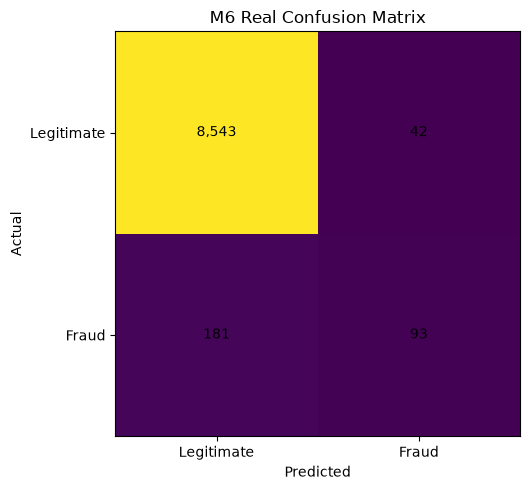

C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X[col] = pd.Categorical(
C:\Users\saket\AppData\Local\Temp\ipykernel_29268\3734488492.py:58: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's cate

M6 Stress FINAL RISK METRICS
True Positives:        93
False Positives:       42
True Negatives:        8,543
False Negatives:       181
Precision:             0.688889
Recall:                0.339416
F1 Score:              0.454768
False Positive Rate:   0.004892
False Negative Rate:   0.660584
Fraud Capture Rate:    0.339416
Baseline Review Count: 2,494
Final Review Count:    2,274
Auto-Resolved:         220
Auto-Resolved Fraud:   3
Auto-Resolved Fraud Rate: 0.013636
Manual Review Reduction: 8.82%

Confusion Matrix
TN: 8,543 | FP: 42
FN: 181 | TP: 93

Confusion Matrix Plot


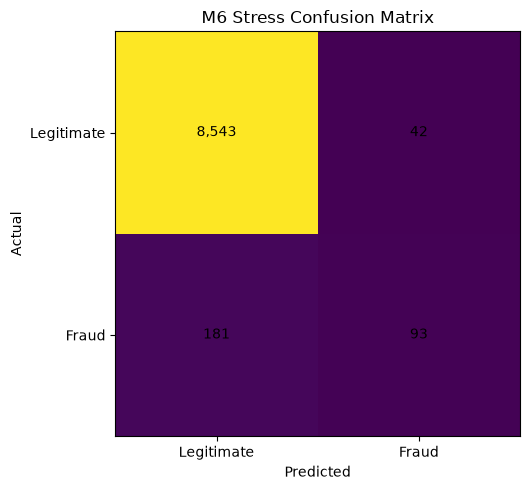

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

for name, df in m6_datasets.items():

    probabilities, mse_scores, anomaly_flags = score_models(
        df
    )

    routing = route_policy(
        probabilities,
        mse_scores,
        anomaly_flags,
        auto_resolve_threshold
    )

    labels = df[
        'isFraud'
    ].to_numpy(
        dtype=np.int8
    )

    predicted_block = routing[
        'block_mask'
    ].astype(np.int8)

    cm = confusion_matrix(
        labels,
        predicted_block
    )

    tn, fp, fn, tp = cm.ravel()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    fraud_capture_rate = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    auto_resolve_mask = routing[
        'auto_resolve_mask'
    ]

    auto_resolved = int(
        auto_resolve_mask.sum()
    )

    auto_resolved_fraud = int(
        (
            auto_resolve_mask
            &
            (labels == 1)
        ).sum()
    )

    auto_resolved_fraud_rate = (
        auto_resolved_fraud / auto_resolved
        if auto_resolved > 0
        else 0.0
    )

    review_only_count = int(
        routing[
            'review_mask'
        ].sum()
    )

    baseline_review_mask = (
        (probabilities >= t_low)
        &
        (probabilities <= t_high)
    )

    baseline_review_count = int(
        baseline_review_mask.sum()
    )

    manual_review_reduction = (
        (
            baseline_review_count
            -
            review_only_count
        )
        /
        baseline_review_count
        *
        100
        if baseline_review_count > 0
        else 0.0
    )

    print("==================================================")
    print(f"{name} FINAL RISK METRICS")
    print("==================================================")

    print(
        f"True Positives:        {tp:,}"
    )

    print(
        f"False Positives:       {fp:,}"
    )

    print(
        f"True Negatives:        {tn:,}"
    )

    print(
        f"False Negatives:       {fn:,}"
    )

    print(
        f"Precision:             {precision:.6f}"
    )

    print(
        f"Recall:                {recall:.6f}"
    )

    print(
        f"F1 Score:              {f1:.6f}"
    )

    print(
        f"False Positive Rate:   {false_positive_rate:.6f}"
    )

    print(
        f"False Negative Rate:   {false_negative_rate:.6f}"
    )

    print(
        f"Fraud Capture Rate:    {fraud_capture_rate:.6f}"
    )

    print(
        f"Baseline Review Count: {baseline_review_count:,}"
    )

    print(
        f"Final Review Count:    {review_only_count:,}"
    )

    print(
        f"Auto-Resolved:         {auto_resolved:,}"
    )

    print(
        f"Auto-Resolved Fraud:   {auto_resolved_fraud:,}"
    )

    print(
        f"Auto-Resolved Fraud Rate: "
        f"{auto_resolved_fraud_rate:.6f}"
    )

    print(
        f"Manual Review Reduction: "
        f"{manual_review_reduction:.2f}%"
    )

    print("\nConfusion Matrix")
    print(
        f"TN: {tn:,} | FP: {fp:,}"
    )
    print(
        f"FN: {fn:,} | TP: {tp:,}"
    )

    print("\nConfusion Matrix Plot")

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.imshow(
        cm
    )

    ax.set_xlabel(
        "Predicted"
    )

    ax.set_ylabel(
        "Actual"
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_xticklabels(
        ['Legitimate', 'Fraud']
    )

    ax.set_yticklabels(
        ['Legitimate', 'Fraud']
    )

    ax.set_title(
        f"{name} Confusion Matrix"
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha='center',
                va='center'
            )

    plt.tight_layout()
    plt.show()
    plt.close()